In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica para que los gráficos se vean bien más adelante
sns.set_theme(style="whitegrid")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [ ]:
https://raw.githubusercontent.com/BryanJimenezUtec/etl-data-pipeline2520552022/refs/heads/main/data/raw/online_gaming_250k_final.csv

In [3]:
# Cargamos el archivo a un DataFrame (le llamaremos 'df')
df = pd.read_csv('https://raw.githubusercontent.com/BryanJimenezUtec/etl-data-pipeline2520552022/refs/heads/main/data/raw/online_gaming_250k_final.csv')

In [5]:
# Imprimimos el tamaño exacto para confirmar que tienes tus 250k registros
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# Vemos las primeras 5 filas para confirmar que los datos se leen bien
display(df.head())

El dataset tiene 250034 filas y 13 columnas.


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [6]:
print("\n--- TIPOS DE DATOS Y MEMORIA ---")
df.info()

print("\n--- RECUENTO DE VALORES NULOS ---")
print(df.isnull().sum())

print("\n--- RECUENTO DE FILAS DUPLICADAS ---")
print(f"Duplicados exactos: {df.duplicated().sum()}")


--- TIPOS DE DATOS Y MEMORIA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250034 entries, 0 to 250033
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PlayerID                   250034 non-null  int64  
 1   Age                        250034 non-null  int64  
 2   Gender                     250034 non-null  object 
 3   Location                   250034 non-null  object 
 4   GameGenre                  250034 non-null  object 
 5   PlayTimeHours              250034 non-null  float64
 6   InGamePurchases            250034 non-null  int64  
 7   GameDifficulty             250034 non-null  object 
 8   SessionsPerWeek            250034 non-null  int64  
 9   AvgSessionDurationMinutes  250034 non-null  int64  
 10  PlayerLevel                250034 non-null  int64  
 11  AchievementsUnlocked       250034 non-null  int64  
 12  EngagementLevel            250034 non-null  object 


In [7]:
# Guardamos el DataFrame original intacto para usarlo en BI
df.to_csv('dataset_limpio_BI.csv', index=False)
print("Archivo para Power BI y SQL guardado exitosamente.")

Archivo para Power BI y SQL guardado exitosamente.


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Hacemos una copia para no alterar el original
df_ml = df.copy()

In [10]:
#2. Eliminamos la llave primaria (ID)
df_ml = df_ml.drop('PlayerID', axis=1)

# 3. Convertimos ordinales a jerarquía numérica
df_ml['GameDifficulty'] = df_ml['GameDifficulty'].map({'Easy': 1, 'Medium': 2, 'Hard': 3})
df_ml['EngagementLevel'] = df_ml['EngagementLevel'].map({'Low': 1, 'Medium': 2, 'High': 3})

In [11]:
# 4. Convertimos nominales a variables binarias (One-Hot Encoding)
df_ml = pd.get_dummies(df_ml, columns=['Gender', 'Location', 'GameGenre'], drop_first=True)

# 5. Escalamos los valores para que tengan el mismo peso
scaler = StandardScaler()
columnas_ml = df_ml.columns
df_ml_scaled = pd.DataFrame(scaler.fit_transform(df_ml), columns=columnas_ml)

print("Transformación matemática completada.")
display(df_ml_scaled.head())

Transformación matemática completada.


,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Gender_Male,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,1.171334,0.613260,-0.500345,0.382859,-0.777382,0.273728,0.937611,-0.049620,-0.000690,0.820274,-0.654116,3.028983,-0.814718,-0.496818,-0.500182,-0.501888,1.999870
1,-0.221281,-0.938328,-0.500345,0.382859,-0.960323,1.010649,-1.461506,-1.099472,-0.000690,-1.219106,-0.654116,-0.330144,1.227419,-0.496818,-0.500182,-0.501888,1.999870
2,-0.917588,-0.548770,-0.500345,-0.896718,1.052026,0.969709,-0.614759,1.070221,1.390313,-1.219106,-0.654116,-0.330144,1.227419,-0.496818,-0.500182,1.992477,-0.500032
3,0.375554,-0.975960,1.998621,-0.896718,-0.228559,-0.197082,0.161426,1.490162,-0.000690,0.820274,-0.654116,-0.330144,1.227419,-0.496818,-0.500182,-0.501888,-0.500032
4,0.176609,0.506524,-0.500345,0.382859,-1.509145,0.744539,1.502109,0.790261,-0.000690,0.820274,1.528780,-0.330144,-0.814718,-0.496818,-0.500182,-0.501888,-0.500032


In [12]:
# Guardamos el dataset transformado
df_ml_scaled.to_csv('dataset_modelo_ML.csv', index=False)
print("Archivo para Minería de Datos guardado exitosamente.")

Archivo para Minería de Datos guardado exitosamente.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset transformado para ML
df_ml = pd.read_csv('dataset_modelo_ML.csv')
print("Dataset para minería cargado exitosamente.")

Dataset para minería cargado exitosamente.


In [14]:
# Calculamos la matriz de correlación
matriz_correlacion = df_ml.corr()

print("Matriz calculada. Aquí tienes una muestra numérica:")
display(matriz_correlacion.iloc[:5, :5]) # Mostramos solo un fragmento para no saturar la pantalla

Matriz calculada. Aquí tienes una muestra numérica:


,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek
Age,1.000000,0.003826,0.004113,-0.000926,0.004150
PlayTimeHours,0.003826,1.000000,-0.003326,0.000018,-0.001984
InGamePurchases,0.004113,-0.003326,1.000000,-0.001024,0.001794
GameDifficulty,-0.000926,0.000018,-0.001024,1.000000,-0.001644
SessionsPerWeek,0.004150,-0.001984,0.001794,-0.001644,1.000000


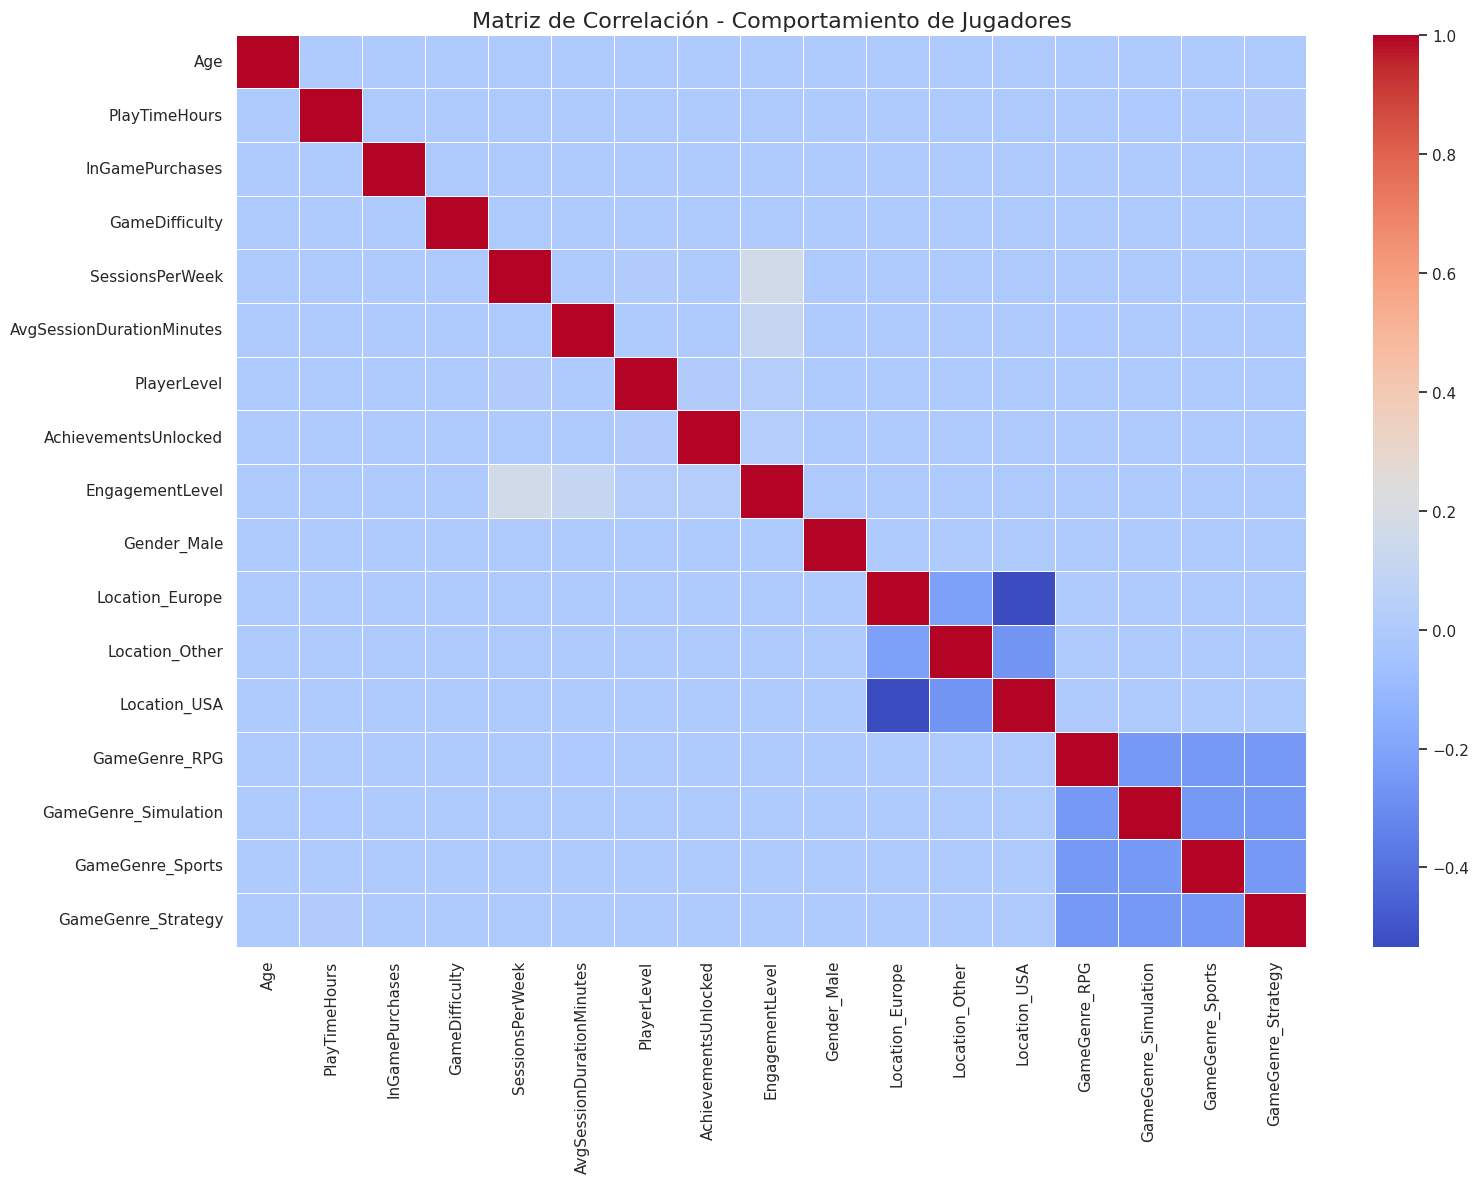

In [15]:
plt.figure(figsize=(16, 12))

# Generamos el gráfico.
# Nota: cmap='coolwarm' pone rojo para correlaciones positivas y azul para negativas.
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlación - Comportamiento de Jugadores', fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
# Convertimos la matriz en una lista de pares y quitamos las correlaciones de una variable consigo misma (1.0)
pares_correlacion = matriz_correlacion.unstack().sort_values(kind="quicksort", ascending=False)
pares_fuertes = pares_correlacion[pares_correlacion != 1.0]

print("--- TOP 5 CORRELACIONES POSITIVAS ---")
print(pares_fuertes.head(10)[::2]) # [::2] es para no repetir A-B y B-A

print("\n--- TOP 5 CORRELACIONES NEGATIVAS ---")
print(pares_fuertes.tail(10)[::2])

--- TOP 5 CORRELACIONES POSITIVAS ---
SessionsPerWeek       EngagementLevel              0.166392
EngagementLevel       AvgSessionDurationMinutes    0.107668
PlayerLevel           EngagementLevel              0.025242
EngagementLevel       AchievementsUnlocked         0.025114
AchievementsUnlocked  PlayerLevel                  0.008298
dtype: float64

--- TOP 5 CORRELACIONES NEGATIVAS ---
GameGenre_Strategy  GameGenre_Simulation   -0.250107
                    GameGenre_Sports       -0.250960
GameGenre_Sports    GameGenre_Simulation   -0.251035
Location_USA        Location_Other         -0.268974
Location_Europe     Location_USA           -0.532920
dtype: float64


USO DE K-MEANS

In [17]:
# Seleccionamos las características numéricas más fuertes del comportamiento
columnas_cluster = ['PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel']

# Creamos un subconjunto de datos solo con esas columnas
X_cluster = df_ml[columnas_cluster]

print("Variables aisladas exitosamente para el clustering.")

Variables aisladas exitosamente para el clustering.


Calculando la inercia (esto puede tomar un minuto por ser 250k registros)...


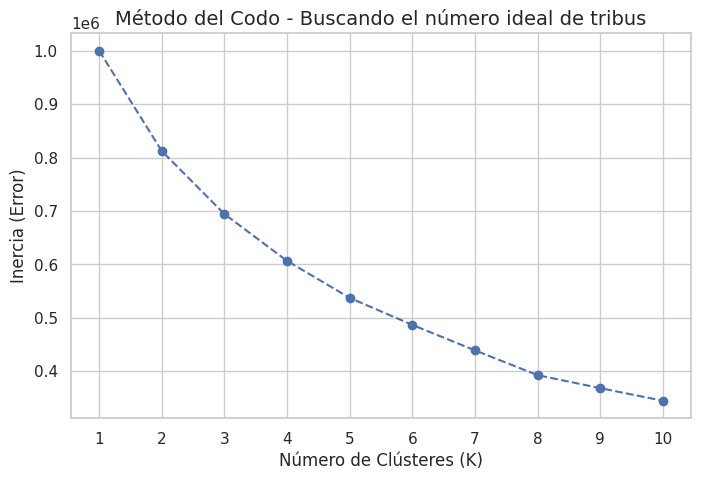

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = [] # Lista para guardar el error matemático de cada intento
rango_k = range(1, 11) # Probaremos de 1 a 10 grupos

print("Calculando la inercia (esto puede tomar un minuto por ser 250k registros)...")
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inercia.append(kmeans.inertia_)

# Graficamos los resultados
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo - Buscando el número ideal de tribus', fontsize=14)
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Error)')
plt.xticks(rango_k)
plt.show()

In [ ]:
# Definimos el K ideal basándonos en la gráfica anterior
k_optimo = 3

# Entrenamos el modelo final
modelo_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# El algoritmo asigna un número de grupo (0, 1 o 2) a cada uno de los 250,000 jugadores
df_ml['Cluster'] = modelo_final.fit_predict(X_cluster)

print("¡Jugadores agrupados! Aquí tienes a qué grupo pertenece cada uno de los primeros 5:")
display(df_ml[['PlayTimeHours', 'SessionsPerWeek', 'PlayerLevel', 'Cluster']].head())

In [19]:
# Definimos el K ideal basado en el codo de tu gráfica
k_optimo = 4

# Entrenamos el modelo final
modelo_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Asignamos el grupo (0, 1, 2 o 3) a cada jugador en nuestro dataset
df_ml['Cluster'] = modelo_final.fit_predict(X_cluster)

print("¡Jugadores agrupados en 4 tribus! Aquí tienes la muestra de los primeros 5:")
display(df_ml[['PlayTimeHours', 'SessionsPerWeek', 'PlayerLevel', 'Cluster']].head())

¡Jugadores agrupados en 4 tribus! Aquí tienes la muestra de los primeros 5:


,PlayTimeHours,SessionsPerWeek,PlayerLevel,Cluster
0,0.613260,-0.777382,0.937611,3
1,-0.938328,-0.960323,-1.461506,1
2,-0.548770,1.052026,-0.614759,1
3,-0.975960,-0.228559,0.161426,0
4,0.506524,-1.509145,1.502109,3


In [20]:
# Cargamos el archivo limpio original (el que tiene textos y el ID)
df_bi = pd.read_csv('dataset_limpio_BI.csv')

# Le pegamos la nueva columna de los 4 grupos
df_bi['Tribu_KMeans'] = df_ml['Cluster']

# Guardamos el archivo definitivo con un nuevo nombre para no confundirnos
nombre_final = 'dataset_BI_con_4_Clusters.csv'
df_bi.to_csv(nombre_final, index=False)

print(f"¡Archivo {nombre_final} generado exitosamente! Listo para presentar.")

¡Archivo dataset_BI_con_4_Clusters.csv generado exitosamente! Listo para presentar.


In [21]:
!pip install mlxtend

In [22]:
from mlxtend.frequent_patterns import apriori, association_rules

# Seleccionamos variables categóricas o binarias (One-Hot) de nuestro df_ml y el nuevo Cluster
columnas_apriori = [col for col in df_ml.columns if 'Gender_' in col or 'Location_' in col or 'GameGenre_' in col]
df_apriori = df_ml[columnas_apriori].copy()

# Convertimos a formato booleano (True/False) que es lo que exige Apriori
df_apriori = df_apriori > 0

print("Datos preparados en formato booleano para el algoritmo de Asociación.")
display(df_apriori.head())

Datos preparados en formato booleano para el algoritmo de Asociación.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Gender_Male,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,True,False,True,False,False,False,False,True
1,False,False,False,True,False,False,False,True
2,False,False,False,True,False,False,True,False
3,True,False,False,True,False,False,False,False
4,True,True,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
# Aplicamos Apriori para encontrar combinaciones frecuentes
itemsets_frecuentes = apriori(df_apriori, min_support=0.05, use_colnames=True)

print(f"Se encontraron {len(itemsets_frecuentes)} patrones o combinaciones frecuentes en el comportamiento de los jugadores.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Se encontraron 23 patrones o combinaciones frecuentes en el comportamiento de los jugadores.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
# Generamos las reglas basadas en la métrica de confianza (mínimo 0.5 o 50%)
reglas_asociacion = association_rules(itemsets_frecuentes, metric="confidence", min_threshold=0.5)

# Ordenamos las reglas por la métrica 'lift' (mientras más alto el lift, más fuerte es la regla matemática)
reglas_asociacion = reglas_asociacion.sort_values(by='lift', ascending=False)

print(f"¡Éxito! Se generaron {len(reglas_asociacion)} reglas lógicas de comportamiento.")

¡Éxito! Se generaron 7 reglas lógicas de comportamiento.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
# Filtramos las columnas más importantes para facilitar la lectura
columnas_ver = ['antecedents', 'consequents', 'support', 'confidence', 'lift']

print("--- TOP 5 REGLAS DE COMPORTAMIENTO ---")
print("Lectura: SI un jugador tiene los rasgos en 'antecedents', ENTONCES tiene los rasgos de 'consequents'")
display(reglas_asociacion[columnas_ver].head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--- TOP 5 REGLAS DE COMPORTAMIENTO ---
Lectura: SI un jugador tiene los rasgos en 'antecedents', ENTONCES tiene los rasgos de 'consequents'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
4,(GameGenre_Simulation),(Gender_Male),0.120408,0.601687,1.006531
6,(GameGenre_Strategy),(Gender_Male),0.119792,0.598896,1.001863
0,(Location_Europe),(Gender_Male),0.179252,0.598193,1.000686
2,(Location_USA),(Gender_Male),0.238048,0.596680,0.998155
5,(GameGenre_Sports),(Gender_Male),0.119928,0.596036,0.997079


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag